# Session 3 — Pixel Losses and Honest Scores 🧪

**Time:** 35–40 minutes  
**Goal:** score a segmentation prediction while excluding ignored border pixels.

You will work with tiny masks where every count is visible, then use the same accumulation pattern used for a validation set.

## 0. Setup

This lab has no download and no training step. Run the cells in order.

In [ ]:
import torch
import torch.nn.functional as F

torch.manual_seed(7)
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
print('PyTorch:', torch.__version__)

## 1. From logits to a mask (5 min)

A model gives two **logits** per pixel: one for background and one for pet. Softmax turns each pair into probabilities that sum to one; `argmax` selects the larger probability.

In [ ]:
# Shape: [batch, classes, height, width]
logits = torch.tensor([[[[3.0, -1.0], [0.2, 1.2]],
                        [[-1.0, 3.0], [1.5, 0.3]]]])
probabilities = logits.softmax(dim=1)
prediction = probabilities.argmax(dim=1)

print('logits shape:       ', tuple(logits.shape))
print('probability sums:\n', probabilities.sum(dim=1))
print('prediction shape:   ', tuple(prediction.shape))
print('predicted labels:\n', prediction[0])
assert torch.allclose(probabilities.sum(dim=1), torch.ones_like(probabilities[:, 0]))
assert prediction.shape == (1, 2, 2)

## 2. Ignored borders do not vote (6 min)

Oxford-IIIT Pet trimaps use `255` for an ambiguous border. It is neither background nor pet, so it must be excluded from both the loss and every metric.

In [ ]:
targets = torch.tensor([[[0, 1], [IGNORE_INDEX, 0]]])
valid = targets != IGNORE_INDEX
loss = F.cross_entropy(logits, targets, ignore_index=IGNORE_INDEX)

print('valid pixels:', int(valid.sum()), 'of', targets.numel())
print('valid mask:\n', valid[0])
print(f'cross-entropy on valid pixels only: {loss.item():.3f}')
assert int(valid.sum()) == 3

## 3. Exercise E1 — accumulate only valid pixels (10 min)

Complete the helper below. It must update a 2×2 confusion matrix whose **rows are true classes** and **columns are predicted classes**. Ignore every target equal to `255`.

In [ ]:

#TODO: update the confusion matrix using only target != IGNORE_INDEX pixels

#* update_confusion() --> acumula los valores de la matriz de confusión
#* scores_from_confusion()--> calcula accuracy e IoU.

#! DONE...
def update_confusion(confusion, target, predicted):
    # Quitamos los pixeles que tienen valor 255
    valid = target != IGNORE_INDEX

    target_valid = target[valid]
    predicted_valid = predicted[valid]

    # Recorremos los pixeles validos y actualizamos la matriz
    for true_value, predicted_value in zip(target_valid, predicted_valid):
        confusion[true_value, predicted_value] += 1

    return confusion


def scores_from_confusion(confusion):
    # Accuracy = predicciones correctas / total de pixeles
    correct = confusion.diag().sum()
    total = confusion.sum()
    accuracy = correct.float() / total.float()

    # IoU para cada clase
    class_iou = torch.zeros(2)

    for i in range(2):
        tp = confusion[i, i]
        fp = confusion[:, i].sum() - tp
        fn = confusion[i, :].sum() - tp

        union = tp + fp + fn

        if union > 0:
            class_iou[i] = tp.float() / union.float()

    return accuracy, class_iou


In [ ]:
# Two small saved predictions: accumulate counts first, then score once.
batch_targets = [
    torch.tensor([[0, 1], [1, IGNORE_INDEX]]),
    torch.tensor([[0, 0], [1, 1]]),
]
batch_predictions = [
    torch.tensor([[0, 1], [0, 1]]),
    torch.tensor([[0, 1], [1, 0]]),
]

confusion = torch.zeros((2, 2), dtype=torch.int64)
for target, predicted in zip(batch_targets, batch_predictions):
    confusion = update_confusion(confusion, target, predicted)

accuracy, class_iou = scores_from_confusion(confusion)
print('rows=true, columns=predicted')
print(confusion)
print(f'dataset pixel accuracy: {accuracy:.3f}')
print(f'background IoU: {class_iou[0]:.3f}; pet IoU: {class_iou[1]:.3f}')
assert confusion.sum().item() == 7  # one of eight cells was ignored
assert torch.all((class_iou >= 0) & (class_iou <= 1))

    **Why accumulate?** Averaging IoU separately for each image gives every image equal weight, even if one has many more valid pixels. A validation report should state its aggregation rule; here we total counts over the dataset before calculating the score.

## 4. Exercise E2 — the worked 4×4 pet IoU (8 min)

For the pet class, find `TP`, `FP`, and `FN`. The ignored lower-right cell must disappear before counting. The expected result is $3/(3+1+1)=0.60$.

In [ ]:
target_4x4 = torch.tensor([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, IGNORE_INDEX],
])
predicted_4x4 = torch.tensor([
    [1, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 1],
])

In [ ]:

# TODO: calculate the pet TP, FP, FN, and IoU while excluding ignored labels
#! DONE...

valid = target_4x4 != IGNORE_INDEX

target_valid = target_4x4[valid]
predicted_valid = predicted_4x4[valid]

# Para la clase pet = 1
tp = ((target_valid == 1) & (predicted_valid == 1)).sum()
fp = ((target_valid == 0) & (predicted_valid == 1)).sum()
fn = ((target_valid == 1) & (predicted_valid == 0)).sum()

pet_iou = tp.float() / (tp + fp + fn).float()

print('TP:', int(tp))
print('FP:', int(fp))
print('FN:', int(fn))
print(f'Pet IoU: {pet_iou.item():.2f}')

assert tp == 3
assert fp == 1
assert fn == 1
assert torch.isclose(pet_iou, torch.tensor(0.60))


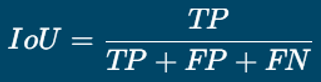

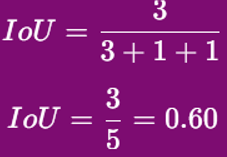

## 5. Accuracy can hide a bad foreground mask (5 min)

Suppose a 10×10 image contains only four pet pixels. A model predicts every pixel as background. It is correct on 96 of 100 pixels, but it finds none of the pet.

In [ ]:
rare_target = torch.zeros((10, 10), dtype=torch.int64)
rare_target[:2, :2] = 1
all_background = torch.zeros_like(rare_target)

rare_confusion = torch.zeros((2, 2), dtype=torch.int64)
rare_confusion = update_confusion(rare_confusion, rare_target, all_background)
rare_accuracy, rare_iou = scores_from_confusion(rare_confusion)
print(f'pixel accuracy: {rare_accuracy:.2%}')
print(f'pet IoU: {rare_iou[1]:.2f}')
assert rare_accuracy == 0.96 and rare_iou[1] == 0.0

> TODO: In one or two sentences, explain why the 96% pixel accuracy above is misleading.


    La precisión del 96 % engaña porque la mayoría de los píxeles son de fondo. El modelo logra una precisión alta con solo predecir el fondo. Sin embargo, la intersección sobre unión (IoU) de la mascota es 0 porque el modelo no detecta ningún píxel de la mascota

## Checkpoint

Before leaving, confirm that you can explain: (1) why `255` is excluded, (2) why the 4×4 pet IoU is 0.60, and (3) why a dataset metric starts from accumulated counts. Next session you will use these metrics to evaluate a pretrained segmentation model.

    # NOTES FOR ME...
    255 es el valor máximo que puede almacenar un canal de color de 8 bits. Representa la intensidad más alta de un color en una imagen digital, sirviendo como puente fundamental entre la electrónica binaria, los píxeles de una pantalla y el entrenamiento de modelos de inteligencia artificial.